# 🚗 Path Planning – Interpolating Discrete Points

This is where the actual task of **planning a path** begins.

In the real world, we rarely have access to a **continuous set of paths**.  
Instead, we deal with a **limited number of discrete points**, such as waypoints from cone detections or sensor outputs.

Our job is to **connect these discrete points** and generate a smooth and feasible trajectory that the vehicle can follow.

---

## Why Do We Need Interpolation?

Since we cannot drive through isolated points, we must **"connect the dots"** to create a **continuous path**.  
There are different methods for this, and choosing the right one depends on the trade-offs between:
- Accuracy
- Smoothness
- Computation time
- Real-time feasibility

You are encouraged to **explore** these topics online and understand them deeply.  
Your final goal is to **optimize the path**, so analyze each method’s **advantages and disadvantages**.

---

## Suggested Resources

### A) Linear and Quadratic Spline Interpolation
- [Linear & Quadratic Spline Intuition](https://www.youtube.com/watch?v=KLUr1A6vyzs)
- [Quadratic Interpolation Explanation](https://www.youtube.com/watch?v=j_jBK7zJ1vU)
- [Quadratic Spline Derivation](https://www.youtube.com/watch?v=kCPMph3cPA8)

### B) Cubic and Higher-Degree Spline Interpolation
- [Cubic Spline Derivation](https://www.youtube.com/watch?v=wMMjF7kXnWA)
- [Cubic Spline Example](https://www.youtube.com/watch?v=gT7F3TWihvk)

> Try solving the example problem yourself before watching the solution.  
> Now imagine scaling that to **hundreds of points** in real-time path planning!

---

## Assignment

## You are given **four discrete points** in increasing order of x:  
`(x₁, y₁), (x₂, y₂), (x₃, y₃), (x₄, y₄)`

Your task is to:
- **Interpolate these points using Cubic Spline Interpolation**
- **Plot the path obtained.**
- **Do NOT use direct library interpolation functions**
    - You can look up source code online for understanding.
    - But make sure you know **exactly what the code is doing**, step by step.

---

## What to Submit

- Your coded solution (with explanation)
- Analysis of cubic splines vs other interpolation methods
    - Think about smoothness, accuracy, computational cost, and usability in real-time systems

Happy Coding & Exploring!

## 🌟 Optional Assignment

Once you're done with the 4-point cubic spline:

Try writing your **own generic cubic spline interpolation** code for **any number of points (n ≥ 4) taken as input**.

- Again, **do not use `scipy`, `numpy.interp`, or any built-in spline functions**.
- Construct and solve the system of equations manually (or using matrix operations) based on the cubic spline conditions.

This will give you an appreciation of the complexity behind interpolation libraries — and how they are optimized.


/tmp/ipykernel_9153/178414626.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


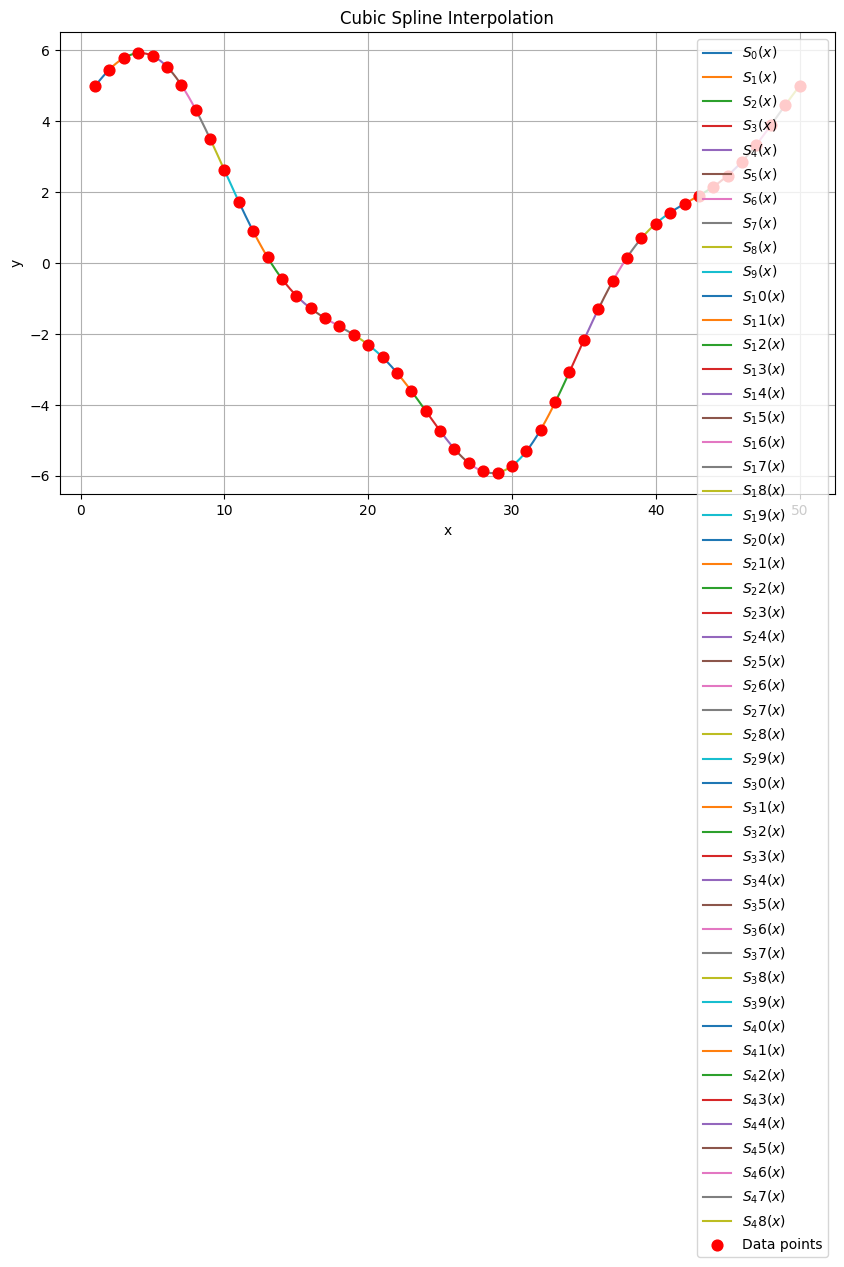

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df=pd.read_csv("loop_track_waypoints.csv")
# x=df[df.columns[0]].values
# y=df[df.columns[1]].values
n=int(input("Enter no of points"))
x,y=[],[]
for i in range (n):
    xi, yi = map(float, input().split())
    x.append(xi)
    y.append(yi)
# n=50
h=[x[i+1]-x[i] for i in range(n-1)]

A=np.zeros((n,n))
rhs=np.zeros(n)

A[0,0]=1
A[n-1,n-1]=1 #natural spline conditions

for i in range(1,n-1):
    A[i, i-1] = h[i-1]
    A[i, i]   = 2 * (h[i-1] + h[i])
    A[i, i+1] = h[i]
    rhs[i] = 3 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])


c=np.linalg.solve(A,rhs)
b=np.zeros(n-1)
d=np.zeros(n-1)
plt.figure(figsize=(10,6))
for i in range(n-1):
    d[i]=(c[i+1]-c[i])/(h[i]*3)
    b[i]=(y[i+1]-y[i])/(h[i]) - h[i]*(2*c[i]+c[i+1])/3
    x_seg = np.linspace(x[i], x[i+1], 200)   # smooth x range per interval
    dx    = x_seg - x[i]
    y_seg = (y[i]
             + b[i] * dx          
             + c[i] * dx**2
             + d[i] * dx**3)

    plt.plot(x_seg, y_seg, label=f'$S_{i}(x)$')

plt.scatter(x, y, color='red', zorder=5, s=60, label='Data points')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()   # FIX 5: plain function call, not a hyperlink

